In [1]:
# predict the cancer 
from sklearn.datasets import load_breast_cancer 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [2]:
# load dataset
# Train/Test split
# Scale the features
# Train
# Prediction
# Evaluation

# Load the dataset
data = load_breast_cancer(as_frame=True)
df = data.frame
x, y = data.data, data.target
# print(df.head())
# print(df.info())
# print(df.describe())
# df.info()
# df.describe()
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## When feature scaling is needed

The breast-cancer features have very different ranges. For example, area measurements are much larger than smoothness measurements. Standardization puts every feature on a comparable scale.

For Logistic Regression, scaling is **strongly recommended** because the solver is an iterative optimizer and because `LogisticRegression()` uses L2 regularization by default. Comparable feature scales make optimization more stable and make the regularization penalty treat coefficients fairly.

The next cell uses the correct workflow: calculate the scaler's mean and standard deviation from `x_train` only with `fit_transform`, then use the same scaler to transform `x_test`. This prevents test-data leakage.

In [3]:
# Train/Test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Train
model = LogisticRegression()
model.fit(x_train_scaled, y_train)

# Predict
y_pred = model.predict(x_test_scaled)
y_proba = model.predict_proba(x_test_scaled)


# Evaluate
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=data.target_names)}")

# Inspect learned coefficients
print("Top 5 most influential features:")
coef_importance = sorted(zip(data.feature_names, model.coef_[0]), key=lambda x: abs(x[1]), reverse=True)
for name, coef in coef_importance[:5]:
    print(f"  {name}: {coef:.4f}")

Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1 Score:  0.9861

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Top 5 most influential features:
  worst texture: -1.2551
  radius error: -1.0830
  worst concave points: -0.9537
  worst area: -0.9478
  worst radius: -0.9476


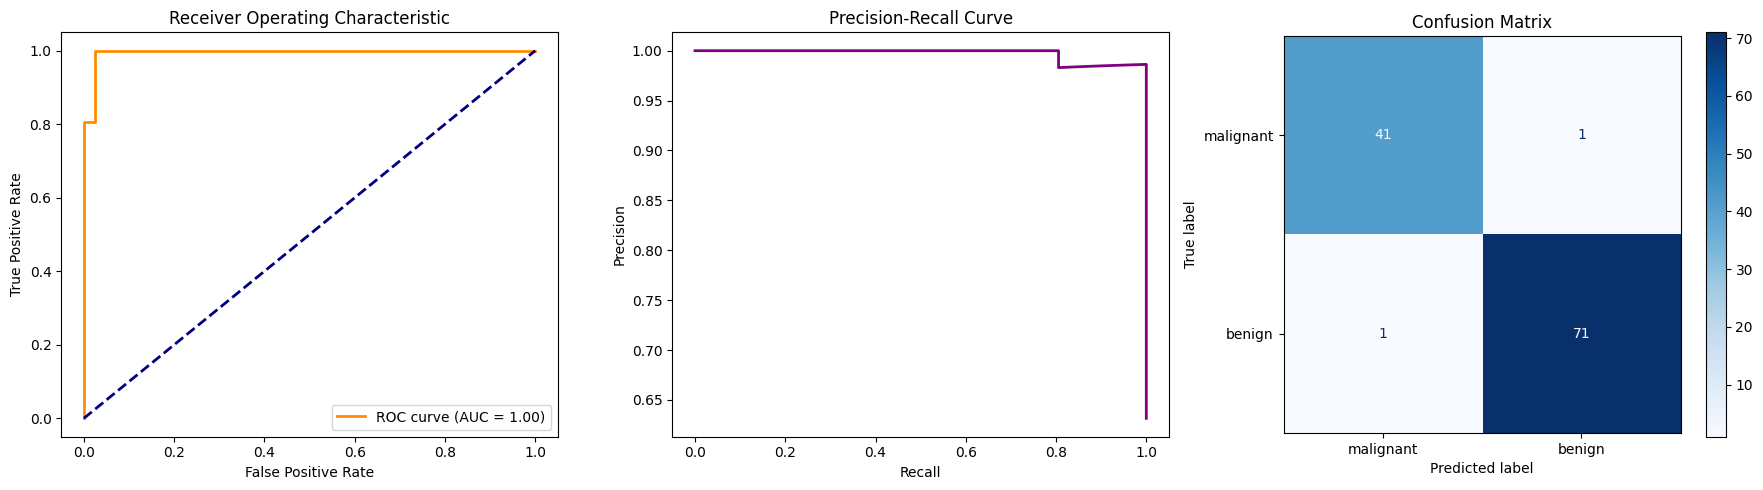

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Receiver Operating Characteristic')
axes[0].legend(loc="lower right")

# PR Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1])
axes[1].plot(recall, precision, color='purple', lw=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[2], cmap='Blues', display_labels=data.target_names)
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()


## Logistic Regression: model, training objective, scaling, and evaluation

Let $X \in \mathbb{R}^{n \times d}$ be the feature matrix: $n$ training examples and $d=30$ breast-cancer features. Let $y \in \{0, 1\}^{n}$ be the binary target labels. In this dataset, `0` is malignant and `1` is benign.

### Formula notation

- $X$: complete feature matrix containing all input values.
- $\in$: “belongs to” or “is an element of.”
- $\mathbb{R}$: set of real numbers.
- $X \in \mathbb{R}^{n \times d}$: $X$ is a real-valued matrix with $n$ rows and $d$ columns. Each row is one patient; each column is one measured feature.
- $n$: number of training examples; $m$: number of test examples; $d$: number of input features.
- $\mathbf{x}_i$: feature values for patient $i$; $x_{ij}$: feature $j$ for patient $i$.
- $y_i$: true class label for patient $i$; $\hat{p}_i$: predicted probability that patient $i$ belongs to class $1$.
- $\boldsymbol{\beta}$: learned coefficient vector; $\beta_0$: learned intercept.

### Model

Logistic Regression first calculates a linear score, called a **logit**:

$$z_i = \mathbf{x}_i^T \boldsymbol{\beta} + \beta_0$$

It then applies the sigmoid function to convert that score to a probability:

$$\hat{p}_i = \sigma(z_i) = \frac{1}{1 + e^{-z_i}}$$

`predict_proba` returns these probabilities. `predict` uses a threshold of $0.5$ by default:

$$\hat{y}_i = \begin{cases} 1 & \text{if } \hat{p}_i \geq 0.5 \\ 0 & \text{if } \hat{p}_i < 0.5 \end{cases}$$

The linear score lets each feature contribute to the decision; sigmoid is used because it maps any score to the probability range $[0, 1]$. The resulting decision boundary is linear.

### Training objective: binary cross-entropy

The model minimizes binary cross-entropy (also called log loss):

$$J(\boldsymbol{\beta}, \beta_0) = -\frac{1}{n} \sum_{i=1}^{n} \left[y_i\log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right]$$

This loss rewards high probability for the correct class and penalizes confident wrong predictions strongly. `LogisticRegression()` also uses L2 regularization by default; conceptually, it adds a penalty proportional to $\lVert\boldsymbol{\beta}\rVert_2^2$ to discourage unnecessarily large coefficients and reduce overfitting. **Minimize** this loss: $0$ is best, and there is no fixed worst value.

### Feature scaling: standardization

$$x_{ij}^{\mathrm{scaled}} = \frac{x_{ij} - \mu_j}{\sigma_j}$$

$$\mu_j = \frac{1}{n}\sum_{i=1}^{n}x_{ij}, \qquad \sigma_j = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_{ij}-\mu_j)^2}$$

$\mu_j$ and $\sigma_j$ are calculated from `x_train` only, then the same values transform `x_test`. This prevents test-data leakage. Scaling is strongly recommended for Logistic Regression because it improves iterative optimization and makes default L2 regularization fair across features.

### Test-set evaluation

For binary classes ordered as $0, 1$, the confusion matrix is:

$$\begin{bmatrix} TN & FP \\ FN & TP \end{bmatrix}$$

- $TN$: predicted $0$ and actual $0$; $FP$: predicted $1$ but actual $0$.
- $FN$: predicted $0$ but actual $1$; $TP$: predicted $1$ and actual $1$.

$$\mathrm{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\mathrm{Precision} = \frac{TP}{TP + FP}, \qquad \mathrm{Recall} = \frac{TP}{TP + FN}$$

$$F_1 = 2 \cdot \frac{\mathrm{Precision}\cdot\mathrm{Recall}}{\mathrm{Precision}+\mathrm{Recall}}$$

- **Accuracy, Precision, Recall, and $F_1$:** **maximize**. Their range is $[0, 1]$, where $1$ is best and $0$ is worst.
- **Accuracy** is the fraction of all correct predictions, but can hide poor performance when classes are imbalanced.
- **Precision** answers: “when the model predicts class $1$, how often is it correct?”
- **Recall** answers: “of all actual class-$1$ examples, how many did the model find?”
- **$F_1$** balances precision and recall.

In this code, sklearn's default `pos_label=1` means the printed Precision, Recall, and $F_1$ describe the benign class. For a cancer-screening task, you may instead want to treat malignant (`0`) as the positive class with `pos_label=0`, then prioritize malignant recall to reduce missed cancers.

In [5]:
import numpy as np
from sklearn.datasets import load_breast_cancer

# Load data
data = load_breast_cancer()
X, y = data.data, data.target   # y: 0 = malignant, 1 = benign

# --- Stratified train/test split (reusing the same logic as your spam split) ---
def stratified_split_numpy(X, y, test_size=0.2, seed=42):
    np.random.seed(seed)
    train_idx, test_idx = [], []
    
    for label_value in np.unique(y):
        class_indices = np.where(y == label_value)[0]
        shuffled = np.random.permutation(class_indices)
        n_test = int(len(shuffled) * test_size)
        test_idx.extend(shuffled[:n_test])
        train_idx.extend(shuffled[n_test:])
    
    train_idx = np.random.permutation(train_idx)
    test_idx = np.random.permutation(test_idx)
    
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = stratified_split_numpy(X, y, test_size=0.2, seed=42)

# --- Manual feature scaling (fit on train only, same rule as before) ---
def fit_scaler(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    return mean, std

def apply_scaler(X, mean, std):
    return (X - mean) / std

mean, std = fit_scaler(X_train)
X_train_scaled = apply_scaler(X_train, mean, std)
X_test_scaled = apply_scaler(X_test, mean, std)

# --- Logistic regression from scratch ---
def add_bias(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack([ones, X])

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def fit_logistic_regression(X, y, lr=0.1, n_iters=1000):
    X_b = add_bias(X)
    n_samples, n_features = X_b.shape
    w = np.zeros(n_features)   # start at zero, as discussed
    
    for i in range(n_iters):
        # 1. Forward pass: compute logits (z) and probabilities (p)
        z = X_b @ w
        p = sigmoid(z)
        
        # 2. Backward pass: compute gradient of binary cross-entropy loss
        # The derivative of BCE loss w.r.t weights simplifies to:
        # (Inputs)^T * (Predicted Probs - True Labels) / batch_size
        gradient = (1 / n_samples) * X_b.T @ (p - y)
        
        # 3. Optimization step: update weights using gradient descent
        w -= lr * gradient
        
        if i % 200 == 0:
            loss = -np.mean(y * np.log(p + 1e-9) + (1 - y) * np.log(1 - p + 1e-9))
            print(f"Iter {i}: loss = {loss:.4f}")
    
    return w

def predict_proba(X, w):
    X_b = add_bias(X)
    return sigmoid(X_b @ w)

def predict(X, w, threshold=0.5):
    return (predict_proba(X, w) >= threshold).astype(int)

# Train
w = fit_logistic_regression(X_train_scaled, y_train, lr=0.1, n_iters=1000)

# Predict
y_pred = predict(X_test_scaled, w)

# --- Manual metrics ---
tp = np.sum((y_pred == 1) & (y_test == 1))
tn = np.sum((y_pred == 0) & (y_test == 0))
fp = np.sum((y_pred == 1) & (y_test == 0))
fn = np.sum((y_pred == 0) & (y_test == 1))

accuracy = (tp + tn) / len(y_test)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"Confusion Matrix:\n[[TN={tn} FP={fp}]\n [FN={fn} TP={tp}]]")

Iter 0: loss = 0.6931
Iter 200: loss = 0.0884
Iter 400: loss = 0.0753
Iter 600: loss = 0.0694
Iter 800: loss = 0.0658

Accuracy:  0.9735
Precision: 0.9722
Recall:    0.9859
F1:        0.9790
Confusion Matrix:
[[TN=40 FP=2]
 [FN=1 TP=70]]


In [ ]:
# wip - numpy scratch
# problem?
# predict that a tumor is malignant - 0 or benign - 1
# data prep
    # load the data
    # convert it in required format
    # train/test split
# train
# evaluation
# metrics

import numpy as np
from sklearn.datasets import load_breast_cancer


data = load_breast_cancer()
print(data.target[:10])
print(data.target_names)
print(data.feature_names)
# print(data.DESCR)


# Architecture
y = w @ x + b
sig = 1 / (1 + np.exp(x))


[0 0 0 0 0 0 0 0 0 0]
['malignant' 'benign']
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
